In [2]:
%pip install tensorflow opencv-python albumentations pillow

  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl.metadata (5.3 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached namex-0.1.0-py3-none-any.whl.metadata (322 bytes)
  Using cached mdurl-0.1.2-py3-none-any.whl.metadata (1.6 kB)
   ---------------------------------------- 0.0/350.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/350.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/350.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/350.6 MB ? eta -:--:--
   ---------------------------------------- 0.3/350.6 MB ? eta -:--:--
   ---------------------------------------- 0.3/350.6 MB ? eta -:--:--
   ---------------------------------------- 0.3/350.6 MB ? eta -:--:--
   ---------------------------------------- 0.5/350.6 MB 465.6 kB/s eta 0:12:32
   -------

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.datasets import mnist
import cv2
from scipy import ndimage
import albumentations as A
import random
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load a sample dataset - we'll use both a tabular dataset and an image dataset
# For tabular data, let's use the Titanic dataset
df = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
# Basic Exploration
print(f"Dataset shape: {df.shape}")
print("\nMissing values per column:")
print(df.isnull().sum())

Dataset shape: (891, 12)

Missing values per column:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [4]:
# Fill missing values
df['Age'].fillna(df['Age'].median(), inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)
df['Cabin'].fillna('Unknown', inplace=True)

# ----- FEATURE ENGINEERING FOR TABULAR DATA -----

In [5]:
# 1. Extract title from name
df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False) #it is called Regular Regex Expression([A-Za-z]+)\.
# Group rare titles
rare_titles = ['Lady', 'Countess','Capt', 'Col', 'Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona']
df['Title'] = df['Title'].replace(rare_titles, 'Rare')
df['Title'] = df['Title'].replace('Mlle', 'Miss')
df['Title'] = df['Title'].replace('Ms', 'Miss')
df['Title'] = df['Title'].replace('Mme', 'Mrs')

In [6]:
# 2. Create family size feature
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1  # +1 for the passenger themselves

In [7]:
# 3. Create is_alone feature
df['IsAlone'] = 0
df.loc[df['FamilySize'] == 1, 'IsAlone'] = 1

In [8]:
# 4. Create fare per person
# Here we are trying to answer the question that how much money was effectively spent per person?
df['FarePerPerson'] = df['Fare'] / df['FamilySize']

In [9]:
# 5. Bin age into categories
# Binning(Discretization) means "converting continuous numerical values into categories".
df['AgeBin'] = pd.cut(df['Age'], bins=[0, 12, 18, 65, 100], labels=['Child', 'Teenager', 'Adult', 'Elderly'])

# pd.cut-> Creates bins based on values/ranges

In [10]:
# 6. Bin fare into categories
df['FareBin'] = pd.qcut(df['Fare'], 4, labels=['Low', 'Medium', 'High', 'Very High'])

# pd.qcut-> Creates bins based on equal number of observations


In [11]:
# 7. Create deck from cabin
df['Deck'] = df['Cabin'].str[0] # Give me the first character of every string.
df['Deck'] = df['Deck'].replace(['T', 'A', 'G'], 'Other')
df['Deck'] = df['Deck'].replace('Unknown', 'U')


In [12]:
# 8. Interaction features
df['Family_Survival'] = df['FamilySize'] * df['Survived']


In [13]:
# 9. Categorical encodings
# One-hot encoding for categorical features
categorical_features = ['Pclass', 'Sex', 'Embarked', 'Title', 'AgeBin', 'FareBin', 'Deck']
df_encoded = pd.get_dummies(df[categorical_features], drop_first=True)

In [14]:
# Combine with numerical features
numerical_features = ['Age', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'IsAlone', 'FarePerPerson']
X = pd.concat([df[numerical_features], df_encoded], axis=1)
y = df['Survived']

In [15]:
# Feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [16]:
# Feature selection using SelectKBest
selector = SelectKBest(f_classif, k=15)
X_selected = selector.fit_transform(X_scaled, y)

In [18]:
# Display top features
feature_scores = pd.DataFrame({
    'Feature': X.columns,      # Feature Names
    'Score': selector.scores_  # Importance Scores
})
top_features = feature_scores.sort_values('Score', ascending=False).head(15)
print("\nTop 15 features:")
print(top_features)


Top 15 features:
              Feature       Score
12           Title_Mr  383.945495
8            Sex_male  372.405724
13          Title_Mrs  117.749079
7              Pclass  115.031272
11         Title_Miss  112.860827
26             Deck_U   99.253142
3                Fare   63.030764
20  FareBin_Very High   51.329338
6       FarePerPerson   45.910184
5             IsAlone   38.353651
22             Deck_D   20.663186
10         Embarked_S   20.374460
23             Deck_E   19.179221
21             Deck_C   11.841661
18     FareBin_Medium    8.208162


In [17]:
# Train a model with the engineered features
X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.25, random_state=42)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [18]:
# Evaluate the model
y_pred = model.predict(X_test)
print("\nModel accuracy with engineered features:", accuracy_score(y_test, y_pred))
print("\nClassification report:")
print(classification_report(y_test, y_pred))


Model accuracy with engineered features: 0.8116591928251121

Classification report:
              precision    recall  f1-score   support

           0       0.85      0.84      0.84       134
           1       0.76      0.78      0.77        89

    accuracy                           0.81       223
   macro avg       0.80      0.81      0.80       223
weighted avg       0.81      0.81      0.81       223



# ----- ADVANCED FEATURE ENGINEERING -----

In [19]:
# 1. Polynomial features (example with a simple subset)
from sklearn.preprocessing import PolynomialFeatures

In [20]:
# Just using Age and Fare for demonstration
poly_features = PolynomialFeatures(degree=2, include_bias=False)
poly_data = poly_features.fit_transform(df[['Age', 'Fare']].fillna(0))

In [21]:
# Display polynomial feature names
feature_names = poly_features.get_feature_names_out(['Age', 'Fare'])
print("\nPolynomial features generated:")
print(feature_names)


Polynomial features generated:
['Age' 'Fare' 'Age^2' 'Age Fare' 'Fare^2']


In [22]:
# 2. PCA for dimensionality reduction
pca = PCA(n_components=10)
X_pca = pca.fit_transform(X_scaled)

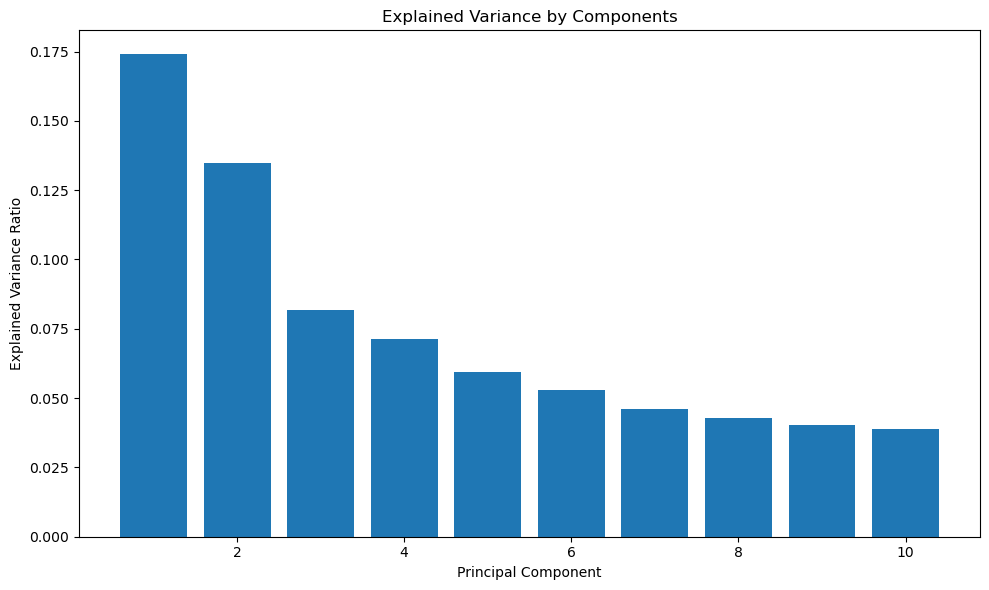

In [23]:
# Plot explained variance ratio
plt.figure(figsize=(10, 6))
plt.bar(range(1, 11), pca.explained_variance_ratio_)
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Explained Variance by Components')
plt.tight_layout()
plt.show()

In [24]:
# Print cumulative explained variance
print("\nCumulative explained variance:")
print(np.cumsum(pca.explained_variance_ratio_))


Cumulative explained variance:
[0.17394189 0.30865766 0.39044823 0.46166279 0.52117907 0.57399528
 0.62017507 0.66317021 0.70334202 0.74223912]


# ----- DATA AUGMENTATION FOR IMAGES -----

In [25]:
# Load MNIST dataset for image augmentation examples
(X_train_img, y_train_img), (X_test_img, y_test_img) = mnist.load_data()

In [26]:
# Normalize the data
X_train_img = X_train_img / 255.0
X_test_img = X_test_img / 255.0

In [27]:
# Expand dimensions for Keras (add channel dimension)
X_train_img = X_train_img.reshape(-1, 28, 28, 1) # -1 -> Number of images (automatic)
X_test_img = X_test_img.reshape(-1, 28, 28, 1)  # 1 -> Grayscale channel

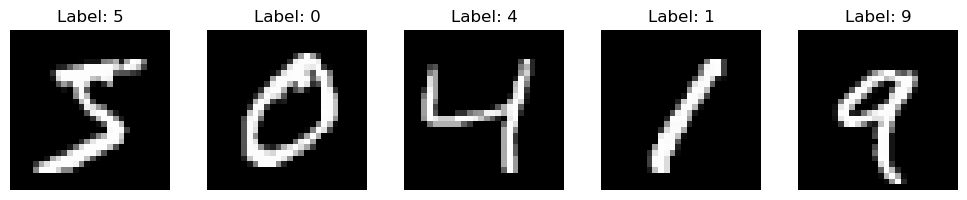

In [28]:
# Display some original images
plt.figure(figsize=(10, 2))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(X_train_img[i].reshape(28, 28), cmap='gray')
    plt.axis('off')
    plt.title(f"Label: {y_train_img[i]}")
plt.tight_layout()
plt.show()


In [29]:
# ----- 1. BASIC IMAGE AUGMENTATION WITH KERAS -----

datagen = ImageDataGenerator(

    rotation_range=10,

    width_shift_range=0.1,

    height_shift_range=0.1,

    zoom_range=0.1,

    shear_range=0.1

)

In [30]:
# Visualize augmented images
augmented_images = []
for x_batch in datagen.flow(X_train_img[:5], batch_size=1, shuffle=False):
    augmented_images.append(x_batch[0])
    if len(augmented_images) >= 15:  # Generate 3 augmented versions of each of the 5 images
        break

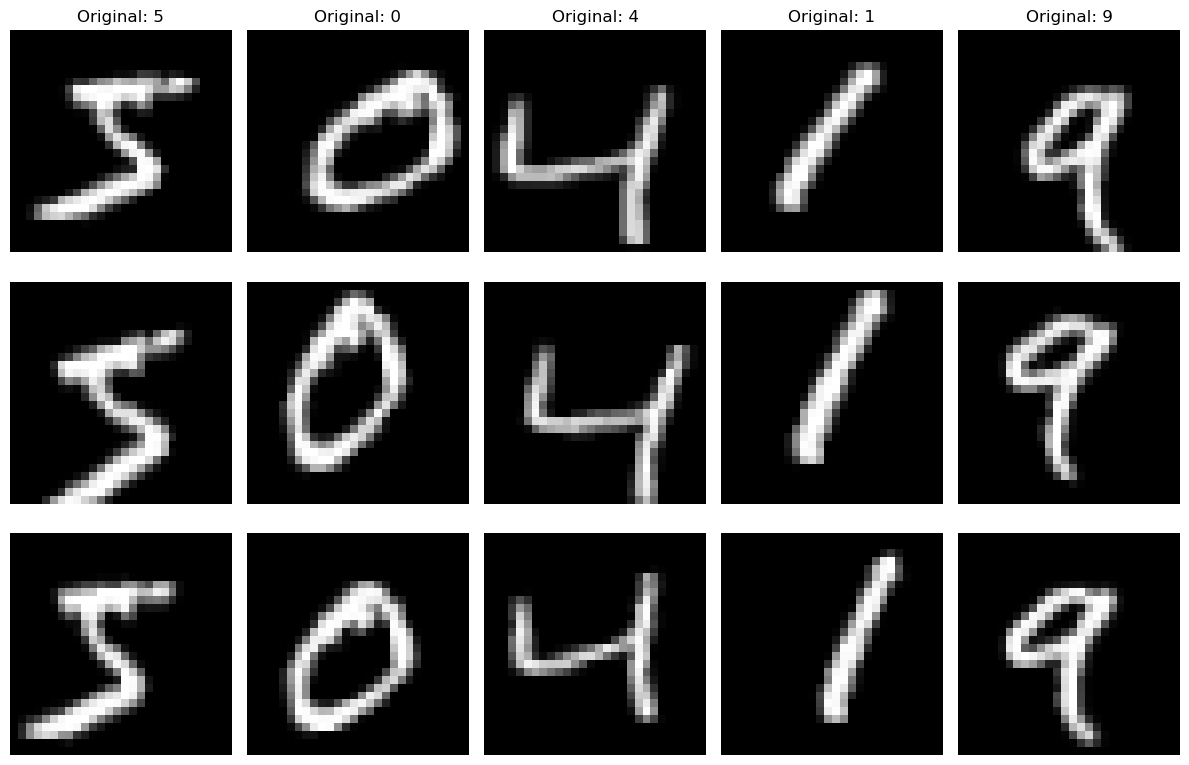

In [31]:
# Display augmented images
plt.figure(figsize=(12, 8))
for i, img in enumerate(augmented_images):
    plt.subplot(3, 5, i+1)
    plt.imshow(img.reshape(28, 28), cmap='gray')
    plt.axis('off')
    if i < 5:
        plt.title(f"Original: {y_train_img[i]}")
plt.tight_layout()
plt.show()

In [32]:
# ----- 2. AUGMENTATION WITH TF.IMAGE -----
def augment_with_tf(image):
    # Convert to float32
    image = tf.cast(image, tf.float32)

    # Random rotation
    image = tf.image.rot90(image, k=tf.random.uniform(shape=[], minval=0, maxval=4, dtype=tf.int32))

    # Random brightness
    image = tf.image.random_brightness(image, max_delta=0.2)

    # Random contrast (Difference between dark and bright regions)
    image = tf.image.random_contrast(image, lower=0.8, upper=1.2)

    # Ensure values are still between 0 and 1
    image = tf.clip_by_value(image, 0.0, 1.0)

    return image

In [33]:
# Apply tf.image augmentation to a few images
augmented_tf_images = []
for i in range(5):
    # Create 3 augmented versions of each image
    for _ in range(3):
        aug_img = augment_with_tf(X_train_img[i]).numpy()
        augmented_tf_images.append(aug_img)

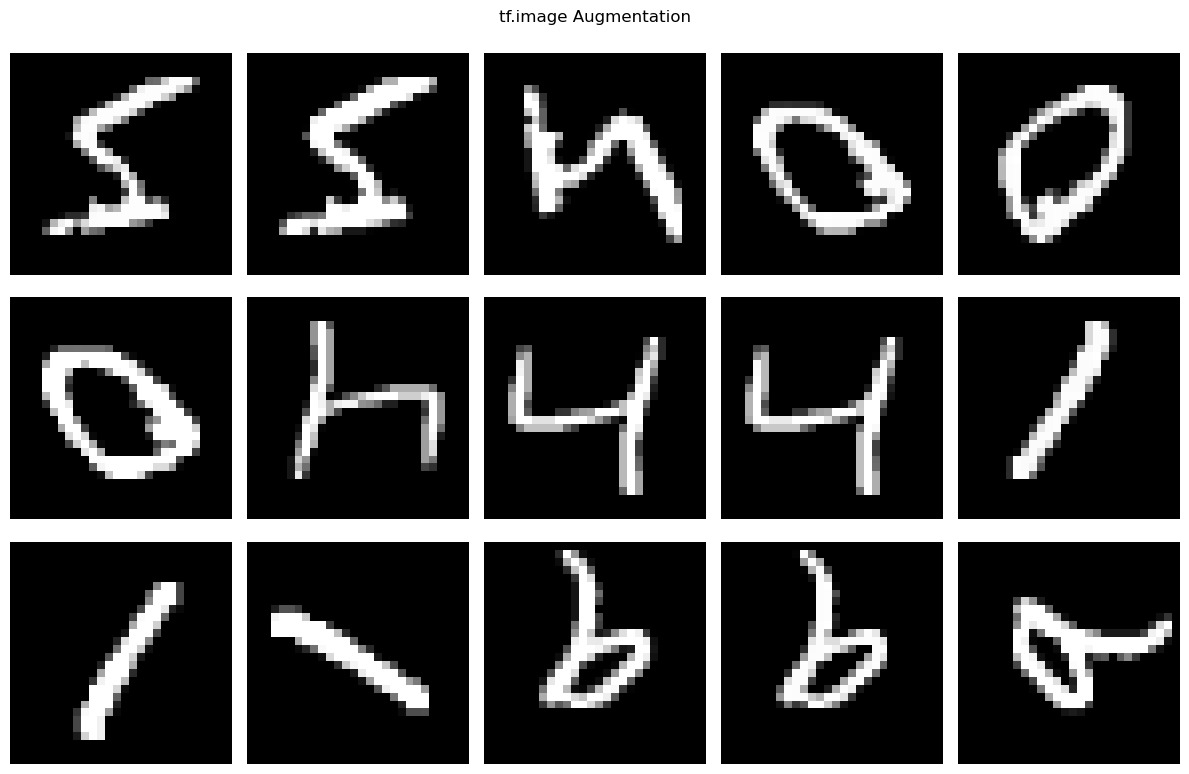

In [34]:
# Display tf.image augmented images
plt.figure(figsize=(12, 8))
for i, img in enumerate(augmented_tf_images):
    plt.subplot(3, 5, i+1)
    plt.imshow(img.reshape(28, 28), cmap='gray')
    plt.axis('off')
plt.suptitle('tf.image Augmentation')
plt.tight_layout()
plt.show()

In [35]:
# ----- 3. AUGMENTATION WITH OPENCV -----

def opencv_augment(image):
    # Convert to 0-255 range and uint8 for OpenCV
    image = (image * 255).astype(np.uint8).reshape(28, 28)

    # Choose a random augmentation
    choice = np.random.choice(['rotate', 'blur', 'zoom', 'original'])

    if choice == 'rotate':
        # Random rotation
        angle = np.random.uniform(-15, 15)
        return ndimage.rotate(image, angle, reshape=False)

    elif choice == 'blur':
        # Add blur
        return cv2.GaussianBlur(image, (3, 3), 0)

    elif choice == 'zoom':
        # Random zoom
        zoom_factor = np.random.uniform(0.8, 1.2)
        height, width = image.shape

        # Compute new dimensions
        new_height = int(height * zoom_factor)
        new_width = int(width * zoom_factor)

        if zoom_factor < 1:  # Zoom out
            # Crop the image
            y_start = (height - new_height) // 2
            x_start = (width - new_width) // 2
            cropped = image[y_start:y_start+new_height, x_start:x_start+new_width]
            # Resize back to original size
            return cv2.resize(cropped, (width, height))
        else:  # Zoom in
            # Resize
            resized = cv2.resize(image, (new_width, new_height))
            # Crop to original size
            y_start = (new_height - height) // 2
            x_start = (new_width - width) // 2
            return resized[y_start:y_start+height, x_start:x_start+width]

    else:
        # Return original
        return image

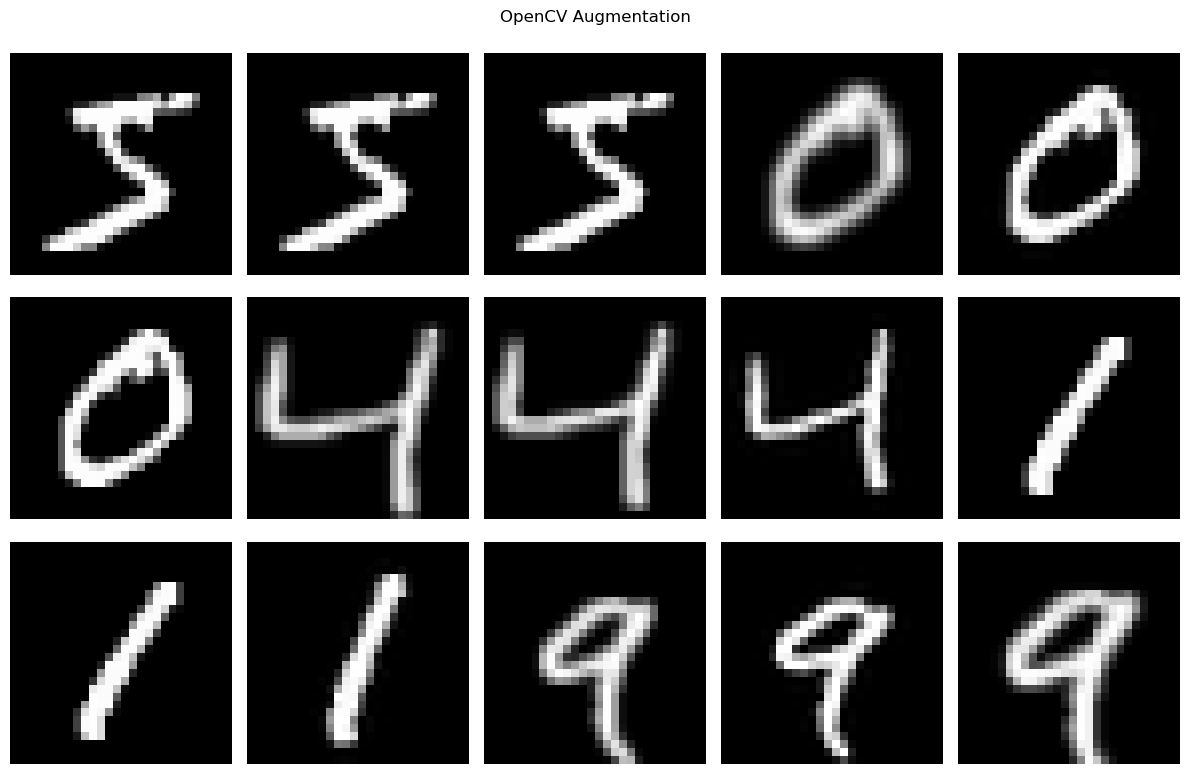

In [36]:

# Apply OpenCV augmentation
opencv_augmented = []
for i in range(5):
    # Create 3 augmented versions of each image
    for _ in range(3):
        aug_img = opencv_augment(X_train_img[i])
        # Normalize back to 0-1
        aug_img = aug_img.astype(np.float32) / 255.0
        opencv_augmented.append(aug_img)

# Display OpenCV augmented images
plt.figure(figsize=(12, 8))
for i, img in enumerate(opencv_augmented):
    plt.subplot(3, 5, i+1)
    plt.imshow(img, cmap='gray')
    plt.axis('off')
plt.suptitle('OpenCV Augmentation')
plt.tight_layout()
plt.show()

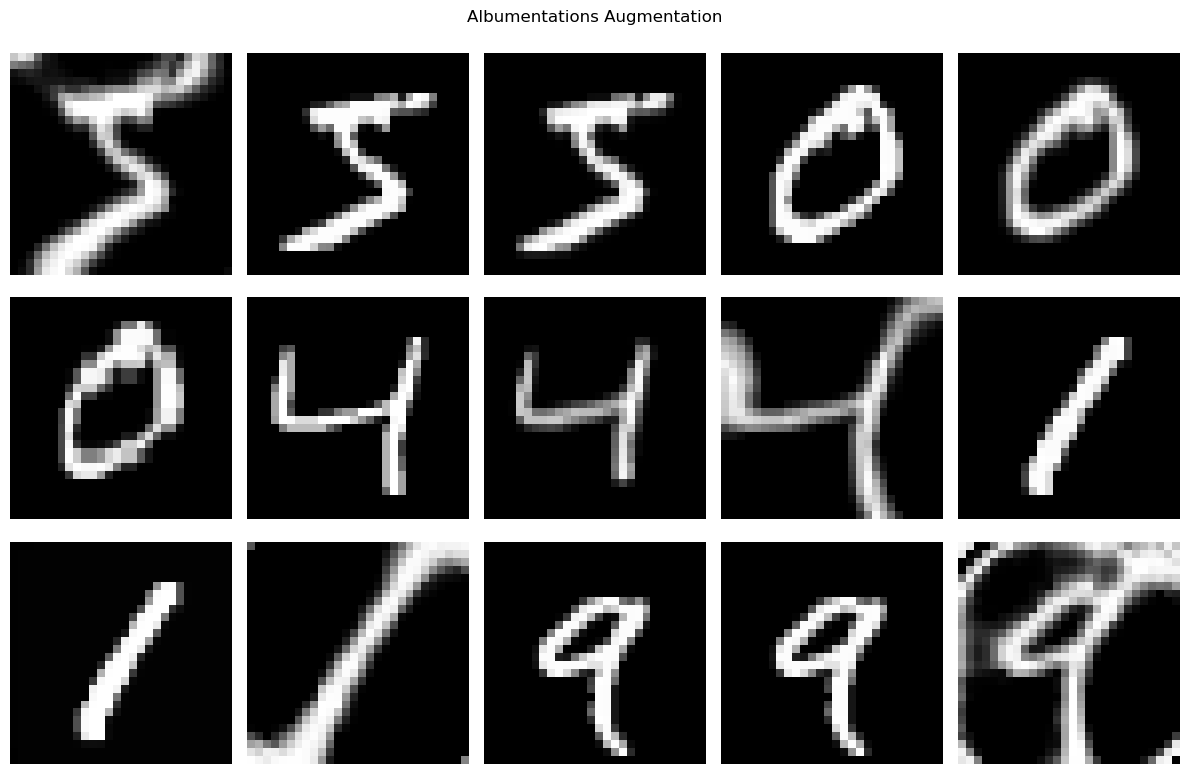

In [37]:
# ----- 4. AUGMENTATION WITH ALBUMENTATIONS -----

def apply_albumentation(image):
    # Convert to 0-255 range and uint8 for Albumentations
    image = (image * 255).astype(np.uint8).reshape(28, 28)

    # Define transformation pipeline
    transform = A.Compose([
        A.OneOf([
            A.RandomBrightnessContrast(p=0.8),
            A.RandomGamma(p=0.8),
        ], p=0.5),
        A.OneOf([
            A.ElasticTransform(alpha=1, sigma=50, alpha_affine=50, p=0.5),
            A.GridDistortion(p=0.5),
            A.OpticalDistortion(distort_limit=2, shift_limit=0.5, p=0.5),
        ], p=0.5),
    ])

    # Apply transformation
    augmented = transform(image=image)['image']

    # Normalize back to 0-1
    return augmented.astype(np.float32) / 255.0

# Apply Albumentations
albu_augmented = []
for i in range(5):
    # Create 3 augmented versions of each image
    for _ in range(3):
        aug_img = apply_albumentation(X_train_img[i])
        albu_augmented.append(aug_img)

# Display Albumentations augmented images
plt.figure(figsize=(12, 8))
for i, img in enumerate(albu_augmented):
    plt.subplot(3, 5, i+1)
    plt.imshow(img, cmap='gray')
    plt.axis('off')
plt.suptitle('Albumentations Augmentation')
plt.tight_layout()
plt.show()


In [38]:
# ----- 5. TEXT DATA AUGMENTATION -----

# Sample texts
texts = [
    "This is a great product, I love it!",
    "The service was terrible and I'm disappointed.",
    "I'm not sure how I feel about this experience.",
    "The food was delicious and the staff was friendly.",
    "This movie is boring and too long."
]

In [39]:
# Simple text augmentation techniques
def swap_words(text):
    words = text.split()
    if len(words) <= 1:
        return text

    idx1, idx2 = sorted(random.sample(range(len(words)), 2))
    words[idx1], words[idx2] = words[idx2], words[idx1]
    return ' '.join(words)

def delete_random_word(text):
    words = text.split()
    if len(words) <= 1:
        return text

    idx = random.randrange(len(words))
    return ' '.join(words[:idx] + words[idx+1:])

def insert_random_word(text, word_list=["really", "very", "somewhat", "quite", "extremely"]):
    words = text.split()
    if not words:
        return text

    idx = random.randrange(len(words))
    word_to_insert = random.choice(word_list)
    return ' '.join(words[:idx] + [word_to_insert] + words[idx:])

In [40]:
# Apply text augmentation
augmented_texts = []
for text in texts:
    augmented_texts.append(("Original", text))
    augmented_texts.append(("Word Swap", swap_words(text)))
    augmented_texts.append(("Word Deletion", delete_random_word(text)))
    augmented_texts.append(("Word Insertion", insert_random_word(text)))

In [41]:
# Display original and augmented texts
print("\nText Data Augmentation Examples:")
for aug_type, text in augmented_texts:
    print(f"{aug_type}: {text}")


Text Data Augmentation Examples:
Original: This is a great product, I love it!
Word Swap: This is I great product, a love it!
Word Deletion: This is a great I love it!
Word Insertion: This is a great product, I quite love it!
Original: The service was terrible and I'm disappointed.
Word Swap: was service The terrible and I'm disappointed.
Word Deletion: The service was terrible and I'm
Word Insertion: The service extremely was terrible and I'm disappointed.
Original: I'm not sure how I feel about this experience.
Word Swap: I'm not sure how I this about feel experience.
Word Deletion: I'm not sure how feel about this experience.
Word Insertion: I'm not sure how I somewhat feel about this experience.
Original: The food was delicious and the staff was friendly.
Word Swap: The food was delicious and the friendly. was staff
Word Deletion: The food was delicious the staff was friendly.
Word Insertion: really The food was delicious and the staff was friendly.
Original: This movie is boring 

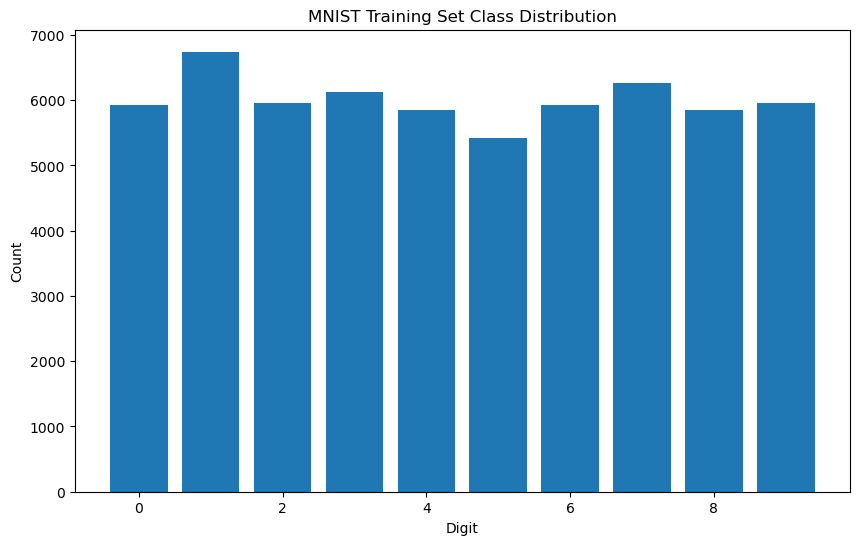

In [42]:
# ----- 6. ADVANCED APPLICATION: AUGMENT TO BALANCE CLASSES -----

# Check distribution of classes in MNIST
unique, counts = np.unique(y_train_img, return_counts=True)
class_distribution = dict(zip(unique, counts))

plt.figure(figsize=(10, 6))
plt.bar(class_distribution.keys(), class_distribution.values())
plt.xlabel('Digit')
plt.ylabel('Count')
plt.title('MNIST Training Set Class Distribution')
plt.show()

In [43]:

def augment_minority_class(X, y, target_class, num_samples):
    # Find samples of the target class
    class_indices = np.where(y == target_class)[0]
    X_class = X[class_indices]

    # If we already have enough samples, no need to augment
    if len(X_class) >= num_samples:
        return X, y

    # Number of augmentations needed
    num_augmentations = num_samples - len(X_class)

    # Create augmentation generator
    datagen = ImageDataGenerator(
        rotation_range=15,
        width_shift_range=0.2,
        height_shift_range=0.2,
        zoom_range=0.2,
        horizontal_flip=True,
        fill_mode='nearest'
    )

    # Generate augmented images
    augmented_images = []
    augmented_labels = []

    for x_batch in datagen.flow(X_class, batch_size=1, shuffle=True):
        augmented_images.append(x_batch[0])
        augmented_labels.append(target_class)
        if len(augmented_images) >= num_augmentations:
            break

    # Convert to numpy arrays
    augmented_images = np.array(augmented_images)
    augmented_labels = np.array(augmented_labels)

    # Combine original and augmented data
    X_balanced = np.vstack([X, augmented_images])
    y_balanced = np.hstack([y, augmented_labels])

    return X_balanced, y_balanced

In [44]:
# Demonstrate balancing a subset of MNIST
# For demonstration, let's use just 100 samples per class initially
X_sample = []
y_sample = []

for digit in range(10):
    indices = np.where(y_train_img == digit)[0][:100]  # Take 100 samples of each digit
    X_sample.extend(X_train_img[indices])
    y_sample.extend(y_train_img[indices])

X_sample = np.array(X_sample)
y_sample = np.array(y_sample)

In [45]:
# Print initial distribution
unique, counts = np.unique(y_sample, return_counts=True)  # Finds all unique classes and counts the number of samples in each class.
print("\nInitial distribution:")
print(dict(zip(unique, counts))) # Finds all unique classes and counts the number of samples in each class.


Initial distribution:
{np.uint8(0): np.int64(100), np.uint8(1): np.int64(100), np.uint8(2): np.int64(100), np.uint8(3): np.int64(100), np.uint8(4): np.int64(100), np.uint8(5): np.int64(100), np.uint8(6): np.int64(100), np.uint8(7): np.int64(100), np.uint8(8): np.int64(100), np.uint8(9): np.int64(100)}


In [46]:
# Let's artificially create an imbalance by removing some '8' samples
eight_indices = np.where(y_sample == 8)[0]
remove_indices = eight_indices[:80]  # Remove 80 samples of digit 8
mask = np.ones(len(y_sample), dtype=bool)
mask[remove_indices] = False  # Mark the selected 80 digit-8 images for removal.

X_imbalanced = X_sample[mask]
y_imbalanced = y_sample[mask]


In [47]:
# Print imbalanced distribution
unique, counts = np.unique(y_imbalanced, return_counts=True)
print("\nImbalanced distribution:")
print(dict(zip(unique, counts)))



Imbalanced distribution:
{np.uint8(0): np.int64(100), np.uint8(1): np.int64(100), np.uint8(2): np.int64(100), np.uint8(3): np.int64(100), np.uint8(4): np.int64(100), np.uint8(5): np.int64(100), np.uint8(6): np.int64(100), np.uint8(7): np.int64(100), np.uint8(8): np.int64(20), np.uint8(9): np.int64(100)}


In [48]:
# Balance the dataset using augmentation
X_balanced, y_balanced = augment_minority_class(X_imbalanced, y_imbalanced, 8, 100)

# Print balanced distribution
unique, counts = np.unique(y_balanced, return_counts=True)
print("\nBalanced distribution after augmentation:")
print(dict(zip(unique, counts)))


Balanced distribution after augmentation:
{np.int64(0): np.int64(100), np.int64(1): np.int64(100), np.int64(2): np.int64(100), np.int64(3): np.int64(100), np.int64(4): np.int64(100), np.int64(5): np.int64(100), np.int64(6): np.int64(100), np.int64(7): np.int64(100), np.int64(8): np.int64(100), np.int64(9): np.int64(100)}


In [49]:
# ----- 7. DEMONSTRATING THE EFFECT OF AUGMENTATION ON MODEL PERFORMANCE -----

# Create a simple CNN model for MNIST
def create_model():
    model = tf.keras.Sequential([
        tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dense(10, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

In [50]:
# Train model on imbalanced data
model_imbalanced = create_model()
history_imbalanced = model_imbalanced.fit(X_imbalanced, y_imbalanced, epochs=5,
                                           validation_split=0.2, verbose=0)


In [51]:
# Train model on balanced data
model_balanced = create_model()
history_balanced = model_balanced.fit(X_balanced, y_balanced, epochs=5,
                                       validation_split=0.2, verbose=0)

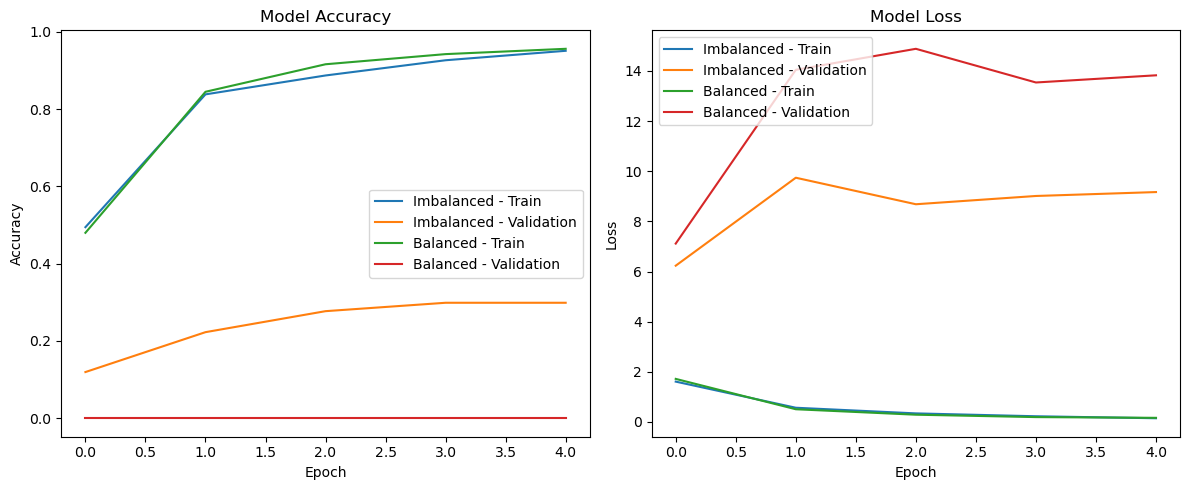

In [52]:
# Compare performance
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_imbalanced.history['accuracy'], label='Imbalanced - Train')
plt.plot(history_imbalanced.history['val_accuracy'], label='Imbalanced - Validation')
plt.plot(history_balanced.history['accuracy'], label='Balanced - Train')
plt.plot(history_balanced.history['val_accuracy'], label='Balanced - Validation')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_imbalanced.history['loss'], label='Imbalanced - Train')
plt.plot(history_imbalanced.history['val_loss'], label='Imbalanced - Validation')
plt.plot(history_balanced.history['loss'], label='Balanced - Train')
plt.plot(history_balanced.history['val_loss'], label='Balanced - Validation')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()

plt.tight_layout()
plt.show()

# Excercise

In [1]:
# 1. Setup and Data Loading

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
df = pd.read_csv(url)


# Display first 5 rows
print("First 5 Rows:")
print(df.head())


# Display the shape of the dataset
print("\nDataset Shape:")
print(df.shape)


# Display missing values in each column
print("\nMissing Values Per Column:")
print(df.isnull().sum())


First 5 Rows:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN

In [2]:
# Fill missing 'Age' values with the median
df['Age'] = df['Age'].fillna(df['Age'].median())

# Fill missing 'Embarked' values with the mode (most frequent value)
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Replace missing 'Cabin' values with 'Unknown'
df['Cabin'] = df['Cabin'].fillna('Unknown')


In [3]:
# 2. Missing Value Imputation

# 3.1 Extract Title from Name
df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)

# 3.2 Group rare titles into 'Rare' and standardize variants
rare_titles = [
    'Lady', 'Countess', 'Capt', 'Col',
    'Don', 'Dr', 'Major', 'Rev',
    'Sir', 'Jonkheer', 'Dona'
]

# Replace rare titles with 'Rare'
df['Title'] = df['Title'].replace(rare_titles, 'Rare')

# Standardize title variants
df['Title'] = df['Title'].replace('Mlle', 'Miss')
df['Title'] = df['Title'].replace('Ms', 'Miss')
df['Title'] = df['Title'].replace('Mme', 'Mrs')

# 3.3 Family Size and IsAlone
# Family Size
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

# IsAlone feature
df['IsAlone'] = 0
df.loc[df['FamilySize'] == 1, 'IsAlone'] = 1

# 3.4 Fare Per Person
df['FarePerPerson'] = df['Fare'] / df['FamilySize']

# 3.5 Age and Fare Binning

# Age Categories
df['AgeBin'] = pd.cut(
    df['Age'],
    bins=[0, 12, 18, 65, 100],
    labels=['Child', 'Teenager', 'Adult', 'Elderly']
)

# Fare Categories (equal-sized quantiles)
df['FareBin'] = pd.qcut(
    df['Fare'],
    4,
    labels=['Low', 'Medium', 'High', 'Very High']
)

# 3.6 Deck from Cabin
# Take the first letter of Cabin
df['Deck'] = df['Cabin'].str[0]

# Replace Unknown cabin values
df['Deck'] = df['Deck'].replace('U', 'U')

# Group rare deck letters
df['Deck'] = df['Deck'].replace(
    ['T', 'A', 'G'],
    'Other'
)


In [4]:
# 3. Feature Engineering

# 3.1 Extract Title from Name

df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)

# 3.2 Group rare titles into 'Rare' and standardize variants
rare_titles = [
    'Lady', 'Countess', 'Capt', 'Col',
    'Don', 'Dr', 'Major', 'Rev',
    'Sir', 'Jonkheer', 'Dona'
]

# Replace rare titles with 'Rare'
df['Title'] = df['Title'].replace(rare_titles, 'Rare')

# Standardize title variants
df['Title'] = df['Title'].replace('Mlle', 'Miss')
df['Title'] = df['Title'].replace('Ms', 'Miss')
df['Title'] = df['Title'].replace('Mme', 'Mrs')


# 3.3 Family Size and IsAlone
# Total family members (including the passenger)
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

# Create IsAlone feature
df['IsAlone'] = 0
df.loc[df['FamilySize'] == 1, 'IsAlone'] = 1

# 3.4 Fare Per Person
df['FarePerPerson'] = df['Fare'] / df['FamilySize']


# 3.5 Age and Fare Binning
# Age categories
df['AgeBin'] = pd.cut(
    df['Age'],
    bins=[0, 12, 18, 65, 100],
    labels=['Child', 'Teenager', 'Adult', 'Elderly']
)

# Fare categories (quartiles)
df['FareBin'] = pd.qcut(
    df['Fare'],
    q=4,
    labels=['Low', 'Medium', 'High', 'Very High']
)

# 3.6 Deck from Cabin

# Extract the first letter of Cabin
df['Deck'] = df['Cabin'].str[0]

# Replace rare deck letters
df['Deck'] = df['Deck'].replace(['T', 'A', 'G'], 'Other')

# Replace unknown cabins with 'U'
df['Deck'] = df['Deck'].replace('Unknown', 'U')


In [6]:
# 4. Encoding and Scaling

# 4.1 One‑hot encode selected categorical columns using pd.get_dummies :contentReference[oaicite:11]{index=11}

categorical = [
    'Pclass',
    'Sex',
    'Embarked',
    'Title',
    'AgeBin',
    'FareBin',
    'Deck'
]

# Convert categorical features into numerical columns
df_encoded = pd.get_dummies(
    df[categorical],
    drop_first=True
)

# 4.2 Combine with numerical features
numerical = [
    'Age',
    'SibSp',
    'Parch',
    'Fare',
    'FamilySize',
    'IsAlone',
    'FarePerPerson'
]

# Combine numerical and encoded categorical features
X = pd.concat(
    [df[numerical], df_encoded],
    axis=1
)

# Target variable
y = df['Survived']

# 4.3 Feature scaling: fit three different scalers and transform X
from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler,
    RobustScaler
)

# Create scaler objects
scaler_std = StandardScaler()
scaler_mm = MinMaxScaler()
scaler_rbv = RobustScaler()

# Scale the features
X_std = scaler_std.fit_transform(X)

X_mm = scaler_mm.fit_transform(X)

X_rb = scaler_rbv.fit_transform(X)


In [7]:
# 5. Feature Selection & Modeling

from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split


# Select top 15 features
selector = SelectKBest(
    score_func=f_classif,
    k=15
)

# Fit and transform the scaled data
X_sel = selector.fit_transform(X_std, y)

# Display the top 15 features and their scores
top_feats = pd.DataFrame({
    'Feature': X.columns,
    'Score': selector.scores_
}).nlargest(15, 'Score')

print("Top 15 Features:\n")
print(top_feats)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_sel,
    y,
    test_size=0.25,
    random_state=42
)

# Train Random Forest Classifier
model = RandomForestClassifier(
    random_state=42
)

model.fit(X_train, y_train)

# Predictions

y_pred = model.predict(X_test)

# Model Evaluation

print("\nAccuracy Score:")
print(accuracy_score(y_test, y_pred))


# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Top 15 Features:

              Feature       Score
12           Title_Mr  383.945495
8            Sex_male  372.405724
13          Title_Mrs  117.749079
7              Pclass  115.031272
11         Title_Miss  112.860827
26             Deck_U   99.253142
3                Fare   63.030764
20  FareBin_Very High   51.329338
6       FarePerPerson   45.910184
5             IsAlone   38.353651
22             Deck_D   20.663186
10         Embarked_S   20.374460
23             Deck_E   19.179221
21             Deck_C   11.841661
18     FareBin_Medium    8.208162

Accuracy Score:
0.8116591928251121

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.84      0.84       134
           1       0.76      0.78      0.77        89

    accuracy                           0.81       223
   macro avg       0.80      0.81      0.80       223
weighted avg       0.81      0.81      0.81       223



Polynomial Feature Names:

['Age' 'Fare' 'Age^2' 'Age Fare' 'Fare^2']


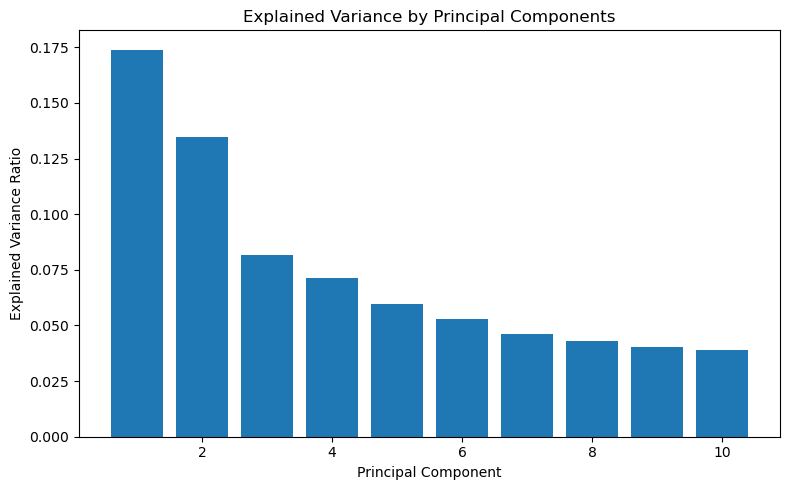


Cumulative Explained Variance:

[0.17394189 0.30865766 0.39044823 0.46166279 0.52117907 0.57399528
 0.62017507 0.66317021 0.70334202 0.74223912]


In [8]:
# 6. Advanced Feature Engineering
from sklearn.preprocessing import PolynomialFeatures

# 6.1 Polynomial Features using sklearn.preprocessing.PolynomialFeatures :contentReference[oaicite:14]{index=14}

# Create polynomial features of degree 2
poly = PolynomialFeatures(
    degree=2,
    include_bias=False
)

# Apply polynomial transformation on Age and Fare
poly_data = poly.fit_transform(
    df[['Age', 'Fare']].fillna(0)
)

# Display the newly created feature names
print("Polynomial Feature Names:\n")
print(poly.get_feature_names_out(['Age', 'Fare']))


# 6.2 PCA for dimensionality reduction :contentReference[oaicite:15]{index=15}
from sklearn.decomposition import PCA

# Keep the first 10 principal components
pca = PCA(n_components=10)

# Apply PCA on standardized data
X_pca = pca.fit_transform(X_std)

# Plot Explained Variance Ratio
plt.figure(figsize=(8, 5))

plt.bar(
    range(1, 11),
    pca.explained_variance_ratio_
)

plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Explained Variance by Principal Components")

plt.tight_layout()
plt.show()

# Print Cumulative Explained Variance

print("\nCumulative Explained Variance:\n")
print(np.cumsum(pca.explained_variance_ratio_))

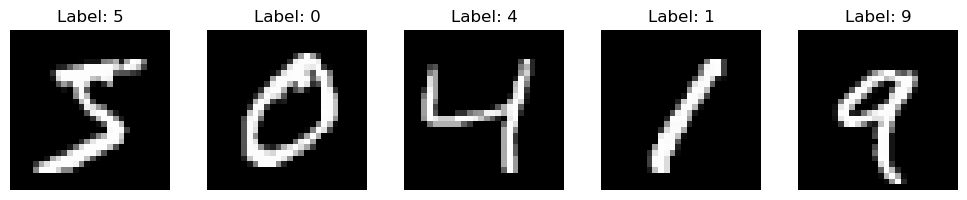

In [9]:
# Load MNIST Dataset

from tensorflow.keras.datasets import mnist

(X_train_img, y_train_img), (X_test_img, y_test_img) = mnist.load_data()

# Normalize the images

X_train_img = X_train_img / 255.0
X_test_img = X_test_img / 255.0

# Reshape to (28,28,1)

X_train_img = X_train_img.reshape(-1,28,28,1)
X_test_img = X_test_img.reshape(-1,28,28,1)

# Display 5 sample images with labels

import matplotlib.pyplot as plt

plt.figure(figsize=(10,2))

for i in range(5):

    plt.subplot(1,5,i+1)
    plt.imshow(X_train_img[i].reshape(28,28),
               cmap='gray')
    plt.title(f"Label: {y_train_img[i]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [10]:
# 8. Text Data Augmentation

import random


# Sample sentences
texts = [
    "I love learning machine learning.",
    "Python is a powerful programming language.",
    "Data augmentation improves model performance.",
    "Titanic is a popular machine learning dataset.",
    "Artificial Intelligence is transforming the world."
]

# Swap two random words
def swap_words(text):

    words = text.split()

    # Can't swap if there is only one word
    if len(words) <= 1:
        return text

    # Pick two random positions
    idx1, idx2 = random.sample(range(len(words)), 2)

    # Swap them
    words[idx1], words[idx2] = words[idx2], words[idx1]

    return " ".join(words)

# Delete one random word

def delete_random_word(text):

    words = text.split()

    if len(words) <= 1:
        return text

    # Randomly choose a word index
    idx = random.randrange(len(words))

    # Delete that word
    del words[idx]

    return " ".join(words)

# Insert a random word from the sentence

def insert_random_word(text):

    words = text.split()

    if len(words) == 0:
        return text

    # Pick a random word from the sentence
    random_word = random.choice(words)

    # Pick a random position
    idx = random.randrange(len(words) + 1)

    # Insert the word
    words.insert(idx, random_word)

    return " ".join(words)

# Display augmented text

for text in texts:

    print("Original Text:")
    print(text)

    print("\nSwap Words:")
    print(swap_words(text))

    print("\nDelete Random Word:")
    print(delete_random_word(text))

    print("\nInsert Random Word:")
    print(insert_random_word(text))

    print("\n" + "-"*50 + "\n")

Original Text:
I love learning machine learning.

Swap Words:
I love machine learning learning.

Delete Random Word:
I love learning learning.

Insert Random Word:
I love learning learning. machine learning.

--------------------------------------------------

Original Text:
Python is a powerful programming language.

Swap Words:
Python is a programming powerful language.

Delete Random Word:
Python a powerful programming language.

Insert Random Word:
Python is a powerful programming programming language.

--------------------------------------------------

Original Text:
Data augmentation improves model performance.

Swap Words:
Data improves augmentation model performance.

Delete Random Word:
Data augmentation improves performance.

Insert Random Word:
performance. Data augmentation improves model performance.

--------------------------------------------------

Original Text:
Titanic is a popular machine learning dataset.

Swap Words:
popular is a Titanic machine learning dataset.

In [11]:
# 9. Class Balancing via Augmentation

from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np

# Compute class distribution of y_train_img

unique, counts = np.unique(y_train_img, return_counts=True)

class_distribution = dict(zip(unique, counts))

print("Class Distribution:")
print(class_distribution)

# Function for class balancing using augmentation

def augment_minority_class(X, y, target_class, num_samples):

    # Find the indices of the target class
    class_indices = np.where(y == target_class)[0]

    # Extract images belonging to that class
    X_class = X[class_indices]


    # If enough samples already exist, return original data
    if len(X_class) >= num_samples:
        return X, y


    # Calculate how many new samples are needed
    num_augmentations = num_samples - len(X_class)


    # Create an ImageDataGenerator
    datagen = ImageDataGenerator(

        rotation_range=15,
        width_shift_range=0.2,
        height_shift_range=0.2,
        zoom_range=0.2,
        horizontal_flip=True,
        fill_mode='nearest'

    )


    # Lists for storing augmented data
    augmented_images = []
    augmented_labels = []


    # Generate augmented images
    for batch in datagen.flow(
            X_class,
            batch_size=1,
            shuffle=True
    ):

        augmented_images.append(batch[0])

        augmented_labels.append(target_class)

        # Stop once required number is reached
        if len(augmented_images) >= num_augmentations:
            break


    # Convert lists to numpy arrays
    augmented_images = np.array(augmented_images)
    augmented_labels = np.array(augmented_labels)


    # Combine original and augmented data
    X_balanced = np.vstack(
        [X, augmented_images]
    )

    y_balanced = np.hstack(
        [y, augmented_labels]
    )


    return X_balanced, y_balanced

Class Distribution:
{np.uint8(0): np.int64(5923), np.uint8(1): np.int64(6742), np.uint8(2): np.int64(5958), np.uint8(3): np.int64(6131), np.uint8(4): np.int64(5842), np.uint8(5): np.int64(5421), np.uint8(6): np.int64(5918), np.uint8(7): np.int64(6265), np.uint8(8): np.int64(5851), np.uint8(9): np.int64(5949)}


c:\Users\IT LAND\miniconda3\envs\ai-bootcamp\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 67ms/step - accuracy: 0.5163 - loss: 1.6291 - val_accuracy: 0.0652 - val_loss: 5.7100
Epoch 2/5
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.8465 - loss: 0.5215 - val_accuracy: 0.2337 - val_loss: 8.7401
Epoch 3/5
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.9144 - loss: 0.3102 - val_accuracy: 0.2609 - val_loss: 8.4465
Epoch 4/5
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.9457 - loss: 0.1997 - val_accuracy: 0.3152 - val_loss: 8.0608
Epoch 5/5
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.9579 - loss: 0.1461 - val_accuracy: 0.2826 - val_loss: 8.9658
Epoch 1/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step - accuracy: 0.5288 - loss: 1.5691 - val_accuracy: 0.0000e+00 - val_loss: 7.9148
Epoch 2/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.8788 - loss: 0.4429 - val_accuracy: 0.0000e+00 - val_loss: 13.8469
Epoch 3/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.9212 - loss: 0.2659 - val_accuracy: 0.0000e+0

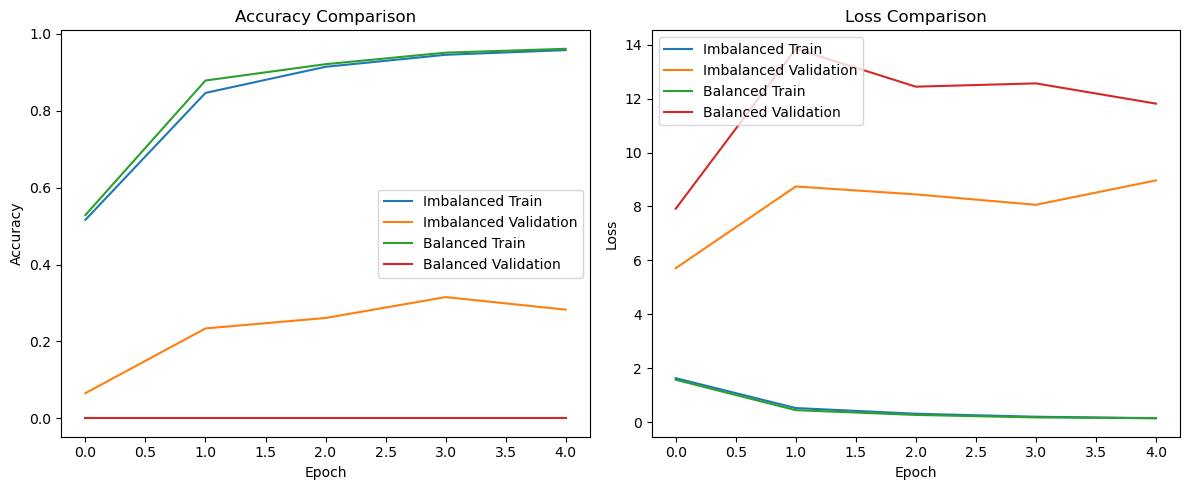

In [12]:
# 10. Effect of Augmentation on Model Performance

import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

# Define a simple CNN model

def create_model():

    model = tf.keras.Sequential([

        tf.keras.layers.Conv2D(
            32,
            (3,3),
            activation='relu',
            input_shape=(28,28,1)
        ),

        tf.keras.layers.MaxPooling2D((2,2)),

        tf.keras.layers.Conv2D(
            64,
            (3,3),
            activation='relu'
        ),

        tf.keras.layers.MaxPooling2D((2,2)),

        tf.keras.layers.Flatten(),

        tf.keras.layers.Dense(
            64,
            activation='relu'
        ),

        tf.keras.layers.Dense(
            10,
            activation='softmax'
        )

    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

# Create an imbalanced dataset

X_sample = []
y_sample = []

# Take first 100 samples from each digit
for digit in range(10):

    indices = np.where(y_train_img == digit)[0][:100]

    X_sample.extend(X_train_img[indices])
    y_sample.extend(y_train_img[indices])


X_sample = np.array(X_sample)
y_sample = np.array(y_sample)


# Remove 80 samples of digit 8

eight_indices = np.where(y_sample == 8)[0]

remove_indices = eight_indices[:80]

mask = np.ones(len(y_sample), dtype=bool)

mask[remove_indices] = False


X_imbalanced = X_sample[mask]
y_imbalanced = y_sample[mask]

# Train model on imbalanced data

model_imbalanced = create_model()

history_imbalanced = model_imbalanced.fit(

    X_imbalanced,
    y_imbalanced,

    validation_split=0.2,

    epochs=5,

    batch_size=32,

    verbose=1

)

# Balance the minority class using augmentation

X_balanced, y_balanced = augment_minority_class(

    X_imbalanced,
    y_imbalanced,

    target_class=8,

    num_samples=100

)

# Train model on balanced data

model_balanced = create_model()

history_balanced = model_balanced.fit(

    X_balanced,
    y_balanced,

    validation_split=0.2,

    epochs=5,

    batch_size=32,

    verbose=1

)

# Plot Accuracy Comparison

plt.figure(figsize=(12,5))

# Training Accuracy
plt.subplot(1,2,1)

plt.plot(
    history_imbalanced.history['accuracy'],
    label='Imbalanced Train'
)

plt.plot(
    history_imbalanced.history['val_accuracy'],
    label='Imbalanced Validation'
)

plt.plot(
    history_balanced.history['accuracy'],
    label='Balanced Train'
)

plt.plot(
    history_balanced.history['val_accuracy'],
    label='Balanced Validation'
)

plt.title("Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# Plot Loss Comparison

plt.subplot(1,2,2)

plt.plot(
    history_imbalanced.history['loss'],
    label='Imbalanced Train'
)

plt.plot(
    history_imbalanced.history['val_loss'],
    label='Imbalanced Validation'
)

plt.plot(
    history_balanced.history['loss'],
    label='Balanced Train'
)

plt.plot(
    history_balanced.history['val_loss'],
    label='Balanced Validation'
)

plt.title("Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

**Experiment: feel free to tweak parameters (e.g., k in SelectKBest, PCA components, augmentation ranges) to see their impact.**